# 1. Attention 등장 배경

## 기존 모델의 한계
- RNN의 한계: 장기 의존성 문제 & Vanishing gradient
    - 데이터가 길어질수록, 데이터의 후반부에서 초반에 위치한 정보가 잘 반영이 되지 않는 문제가 발생
- LSTM의 한계: 계산이 복잡하고 시간이 오래 걸림, 긴 문장에 있어서는 Vanishing gradient가 발생
- seq2seq의 문제: **병목현상**
    - 입력 문장의 모든 정보를 하나의 고정된 Context Vector에 압축 -> 입력 문장이 길어지면 중요 정보 손실

## ATTENTION
- 중요한 정보에 더 높은 가중치 부여
- seq2seq와 달리 출력 시점마다 새로운 context vector를 동적으로 계산 **병렬화**
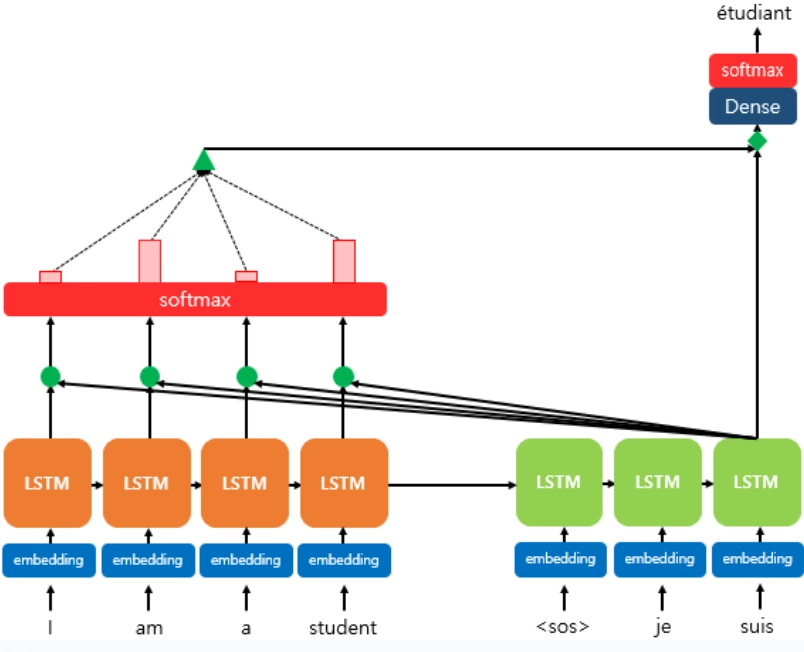 
- ATTENTION의 과정:
    1. 입력을 벡터 형태로 변환
    2. 단어별 중요도 계산   
        - 관련도 점수 계산: 단어들 간 유사성 측정
        - 중요도 배분: **어텐션 가중치**
    3. 중요도에 따른 입력 정보 조합 
- ATTENTION의 장점: 
    - 시간 경과에 대한 유연성: RNN의 장기 의존성 문제 완화
    - 공간에 대한 유연성: CNN과 달리 픽셀 간 거리 상관없이 전역적인 관계 학습
    - **병렬화**: self-attention에서 문장 내 모든 단어의 관계를 한번에, 독립적으로 계산할 수 있음

## ATTENTION is All You Need
- transformer의 등장: RNN의 순환 구조를 완전히 제거 -> self-attention에 기반한 Transformer 모델
- Attention만으로 좋은 성능을 낼 수 있음을 증명 -> 모델 학습 속도를 획기적으로 단축
- 파급효과:
    - **LLM**의 탄생: 트랜스포머는 BERT와 GPT라는 두 거대 모델의 직접적인 기반
    - **NLP** 평정: 거의 모든 자연어 처리 분야에서 트랜스포머 기반 모델들이 표준으로 자리잡게 됨
    - 타 분야로의 확장: AI를 컴퓨터 비전(Vision Transformer), 음성 처리, 신약 개발 등 모든 영역으로 확장시킴

## Transformer
- RNN의 순차적인 계산 방식을 완전히 버리고, **어텐션(Attention)만으로** 문장의 의미와 구조를 파악하는 모델
- Transformer의 핵심 기술:
    - **Self-Attention**: 문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지 한 번에 파악하는 기술
    - **Multi-Head Attention**: 셀프 어텐션을 여러 개의 머리(Head)로 동시에, 서로 다른 관점에서 실행
    - **Positional Encoding**: 단어의 위치 정보를 벡터에 추가하여 각 단어가 문장의 몇 번째 위치에 존재하는지 알 수 있음

# 2. Self-Attention

## 2-1. Query, Key, Value
- Q : Query
    - **'질문'** 또는 **'요청'** / 알고 싶거나 초점을 맞추는 대상
- K : Key 
    - 모든 검색 대상이 달고 있는 **'이름표'** 또는 **'색인'**
- V : Value
    - 키와 한 쌍으로 묶여 있는 **'실제 내용물'**
    
## 2-2. 기존 Cross-Attention vs. Self-Attention
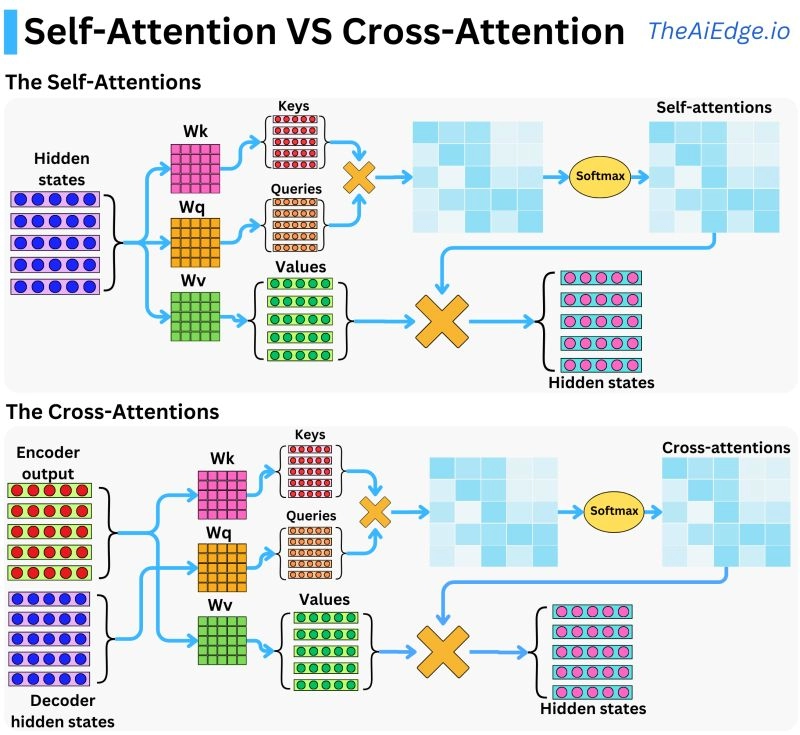  
| 구분 | 기존 어텐션 (Cross-Attention) | 셀프 어텐션 (Self-Attention) |
|---|---|---|
| 핵심 아이디어 | 번역할 문장을 슬쩍슬쩍 보면서 단어를 생성 | 문장 자체를 뜯어보며 내부 관계를 파악 |
| 작동 방식 | 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘 | 한 문장 내 모든 단어끼리 서로의 관계를 계산 |
| 참조 대상 | 서로 다른 시퀀스 (인코더 ↔ 디코더) | 동일한 시퀀스 (문장 내부 ↔ 문장 내부) |
| 주요 목적 | 인코더-디코더 연결, 정보 병목 현상 해소 | 시퀀스 내부의 문맥 및 의존 관계 파악 |
| 기반 아키텍처 | RNN (LSTM, GRU) | 트랜스포머 (Attention Only) |
| 병렬 처리 | 불가능 (순차적) | 가능 |

- Self-Attention:
    - 문장 자체를 뜯어보며 내부 관계를 파악
    - Query와  Key - Value쌍이 같은 시퀀스에서 출력
- 과정:
    1. **벡터 임베딩**: 각 단어를 고유한 특징을 담은 벡터로 변환
    2. **내정 및 정렬 점수**: 모든 단어 벡터끼리 서로 얼마나 관련이 깊은지 '관계 점수' 계산
    3. **소프트맥스 & 어텐션 가중치**: 계산된 관계 점수를 총합이 1이 되는 확률값, 즉 'Attention Weight'로 변환
        - **어텐션 가중치**: 특정 시점에서 특정 입력 요소의 영향을 강조하거나 약화하는 데 사용
    4. 새로운 벡터 생성: 문장 내 다른 단어들의 정보를 자신에게 맞게 조합하여, “문맥이 완벽하게 반영된 새로운 프로필(벡터)”가 됨

## 2-3. Scaled Dot-Product Attention
- Dot-Product Attention: Attention Score를 계산하는 가장 기본적인 방법
    - 쿼리(Query)와 키(Key) 벡터를 내적(Dot Product)하여 유사도 측정
    - **문제점**: Attention Score의 극단화
        - 벡터 차원이 커질수록 내적값이 지나치게 커지거나 작아질 수 있음 ->  Vanishing Gradient 문제
- **Scaled Dot-Product Attention**: 현재 트랜스포머 방식의 표준
    - Dot-Product Attention 과정에서 내적을 진행한 후, 값의 크기를 맞추는 **스케일링 과정 추가**
    - Cross-Attention : 현재 생성 중인 단어가, 입력 문장에서 어떤 단어들에 집중해야 하는지를 반영한 Context Vector
    - Self-Attention : 문장 내 다른 단어들과의 관계를 반영한 문맥적 표현


# 3. Multi-Head Attention

## 3-1. multi-head attention 
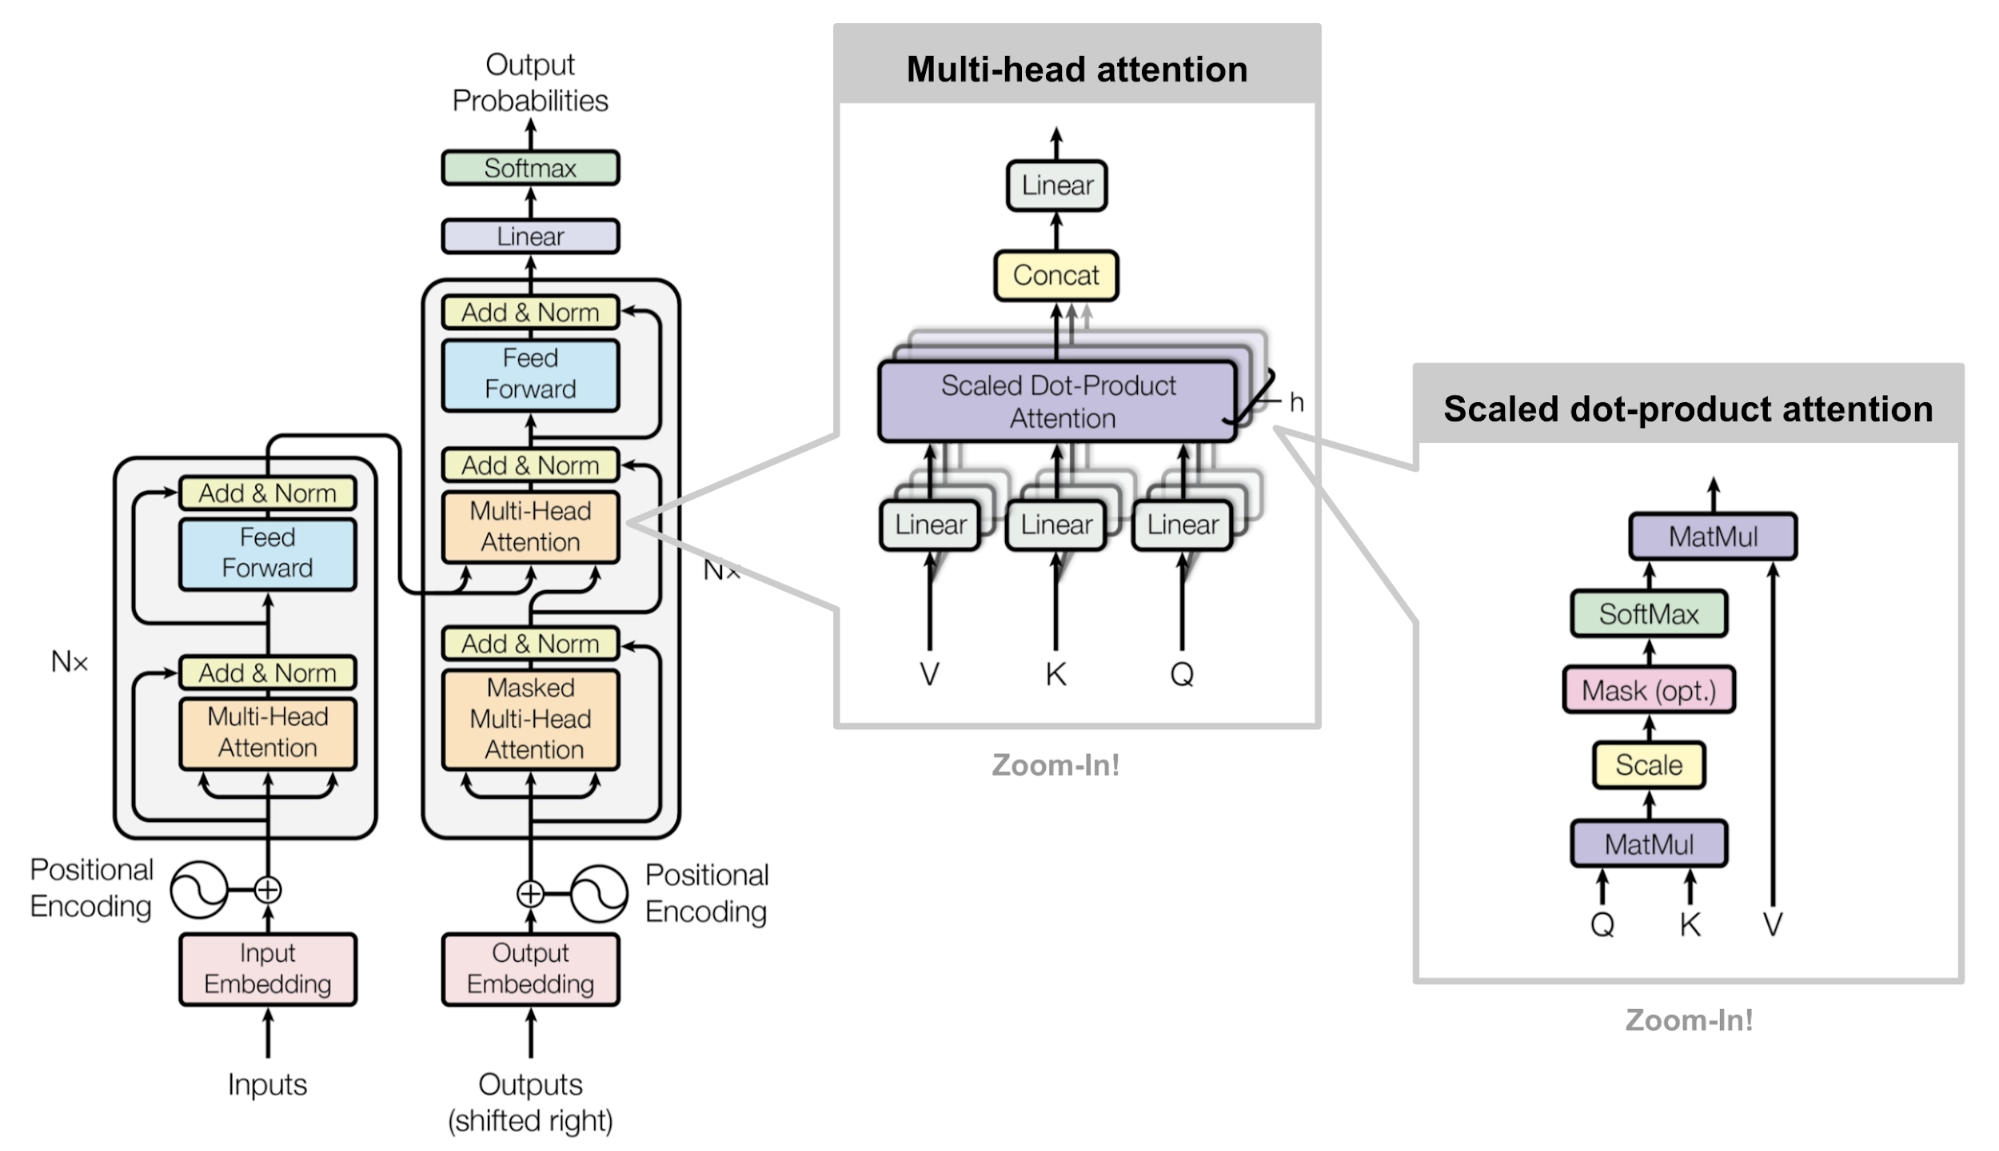  
- encoder에서 1번
- decoder에서 2번
    - Masked Multi-Head Attention: 현재까지 생성된 단어들만 참고
    - Encoder-Decoder Attention: Encoder가 이해한 입력 문장 정보 참고
- Single-Head Attention: 
    - 문장 내 단어들 간의 관계를 파악하기 위해 하나의 가중치 행렬만을 학습하고 번역에 사용
    - 하나의 어텐션 분포 안에서 각 단어 간 문법적인 관계, 의미적인 관계, 위치 관계 등 모든 종류의 정보를 한 번에 담아 가중 평균 구함 -> 각 단어 간의 중요한 관계를 놓칠 수 있음
- **Multi-Head Attention**:
    - 한 단어와 다른 단어 간의 관계를 여러 차원으로 나누어 병렬로 학습
    - 512차원의 입력 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러 번 계산

## 3-2. Multi-Head Attention 작동 방식
1. 분할 (Projection) - 8명의 헤드에 단어 벡터 할당
    - 512차원의 큰 문제 하나를 서로 다른 관점을 담은 8개의 독립적인 64차원짜리 작은 벡터(Q, K, V 세트)들로 분할
2. 병렬 어텐션 계산 - 각 헤드들이 각자 분석 수행
    - 8개의 헤드가 서로에게 전혀 간섭하지 않고, 병렬로 Scaled Dot-Product Attention을 계산
    - 각 헤드의 관점에서 문맥을 이해한 64차원의 결과 벡터 산출
3. 결합 및 최종 투영
    - 8개의 64차원 결과 벡터들을 순서대로 이어 붙여 하나의 거대한 512차원 벡터를 만듦

# 4. Transformer 전체 아키텍처

## 4-1. 트랜스포머의 전처리 단계
1. 토큰화 (Tokenization): 입력 텍스트를 모델이 처리할 수 있는 단위(tokens)로 나누는 첫 번째 단계
2. 임베딩 (Embedding): 각 토큰은 임베딩 단계에서 숫자의 벡터로 변환
3. Positional Encoding: 단어들의 순서 정보 를 임베딩 벡터에 추가하는 단계

## 4-2. 트랜스포머의 Encoder와 Decoder
- **Encoder**: 입력 문장을 이해하고 요약된 의미 벡터로 변환하는 역할
- 인코더 레이어:
    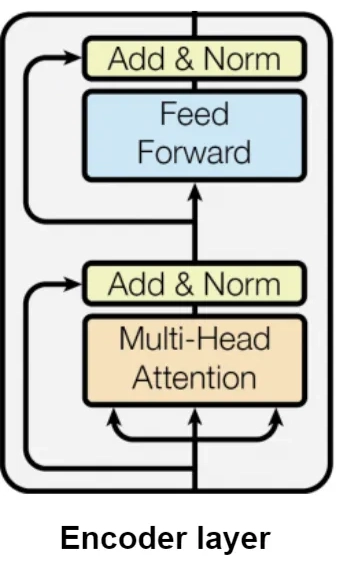  
    - Multi-Head Attention
    - Feed-Forward: 입력 벡터의 차원을 확장하고 비선형 변환(ex: ReLU)을 적용하여 새로운 표현을 생성하는 신경망 구조, 단어에 대해 심층 분석
    - Residual connections (잔차 연결): 기울기 소실 및 폭주 현상 방지를 위해 출력에 입력값을 바로 전달
- **Decoder**: Encoder가 분석한 입력 문장의 의미 벡터를 받아서 출력 문장을 순차적으로 생성하는 역할
- 디코더 레이어:
    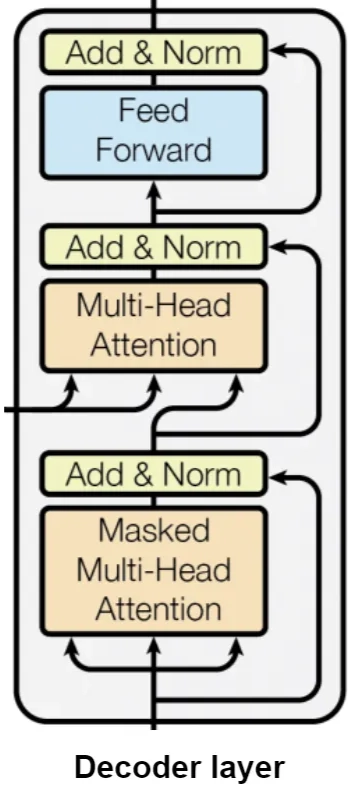  
    - Masked Multi-Head Attention: 모델이 이미 생성된 단어들(과거 정보)만을 기반으로 다음 단어를 예측하도록 강제
    - Encoder-Decoder Multi-Head Attention (Cross-Attention): 디코더가 인코더의 출력(Context)을 참고하면서 현재 생성 중인 단어를 입력 문장의 의미와 연결하는 과정, 디코더가 입력 문장 중 어떤 부분에 주목해야 하는지를 학습
    - Feed-Forward Layer

## 4-3. 전체 모델 흐름
1. 입력 준비: 문장을 [의미 + 위치] 벡터로 바꾸기
    - 임베딩: 각 단어의 의미를 담은 숫자 벡터
    - 포지셔널 인코딩: 위치 벡터를 의미 벡터에 더하기
2. 인코더: 입력 문장의 [문맥적 의미] 깊이 이해하기
    - 셀프 어텐션: 특정 단어가 문장에서 어떤 의미 갖는지 파악
    - 관계 점수 계산: Q와 K의 내적(Dot Product)으로 단어 간 관계 점수를 구하고, Softmax 로 확률 분포(가중치)로 변환
    - 가중합: 계산된 가중치를 V 벡터에 곱하고 모두 더하여 새로운 벡터 생성
    - 멀티-헤드: 여러 개의 어텐션 헤드를 통해 다양한 관점에서 문맥 파악
3. 디코더: 번역 문장을 [한 단어씩] 생성하기
    - <start> 토큰을 시작으로 masked-self-attention으로 이전 토큰만을 참고해 문맥 형성
    - Encoder–Decoder Attention